📊 STATISTICAL SUMMARY OF THE DATASET
         Survived      Pclass         Age       SibSp       Parch        Fare
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.361582    0.523008    0.381594   32.204208
std      0.486592    0.836071   13.019697    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   22.000000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   35.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200

🎯 FEATURE CORRELATION WITH SURVIVAL
Survived       1.000000
Sex_Numeric    0.543351
Fare           0.257307
Parch          0.081629
SibSp         -0.035322
Age           -0.064910
Pclass        -0.338481
Name: Survived, dtype: float64


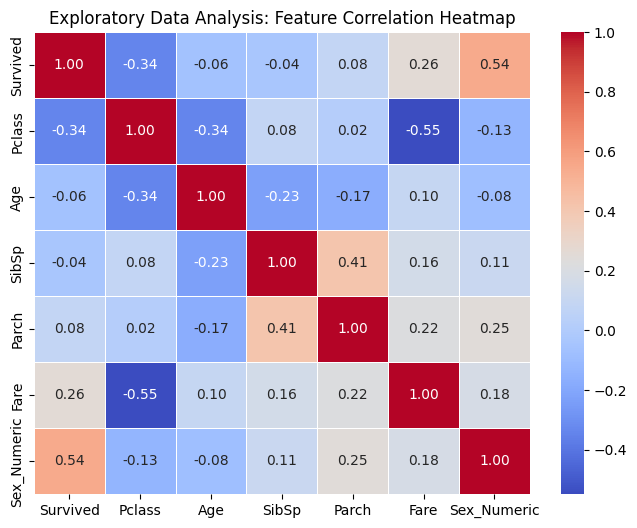

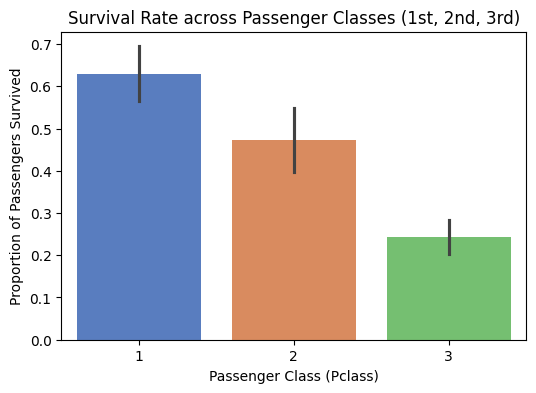

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('/content/Titanic-Dataset.csv')

# Preprocess missing values quickly for accurate analysis
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['Sex_Numeric'] = df['Sex'].map({'male': 0, 'female': 1})

print("="*50)
print("📊 STATISTICAL SUMMARY OF THE DATASET")
print("="*50)
# Display descriptive statistics for numerical columns
print(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].describe())

print("\n" + "="*50)
print("🎯 FEATURE CORRELATION WITH SURVIVAL")
print("="*50)
# 2. Compute correlation matrix for numeric features
numeric_cols = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_Numeric']]
correlation_matrix = numeric_cols.corr()
print(correlation_matrix['Survived'].sort_values(ascending=False))

# 3. Visual Insight 1: Heatmap of Feature Correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Exploratory Data Analysis: Feature Correlation Heatmap')
plt.show()

# 4. Visual Insight 2: Passenger Class vs. Survival Rate
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Pclass', y='Survived', hue='Pclass', palette='muted', legend=False)
plt.title('Survival Rate across Passenger Classes (1st, 2nd, 3rd)')
plt.ylabel('Proportion of Passengers Survived')
plt.xlabel('Passenger Class (Pclass)')
plt.show()